In [1]:
import torch.nn as nn
import torch
from abc import abstractmethod

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## Change of variable formula

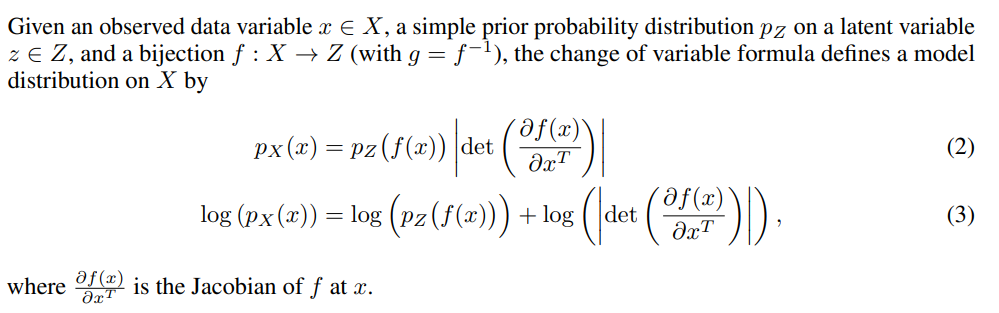

## Coupling Layer

- Computing the Jacobian of functions with high-dimensional domain and codomain and computing
the determinants of large matrices are in general computationally very expensive.

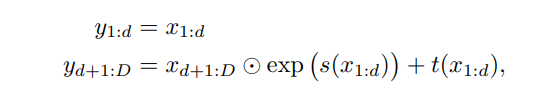

## Properties
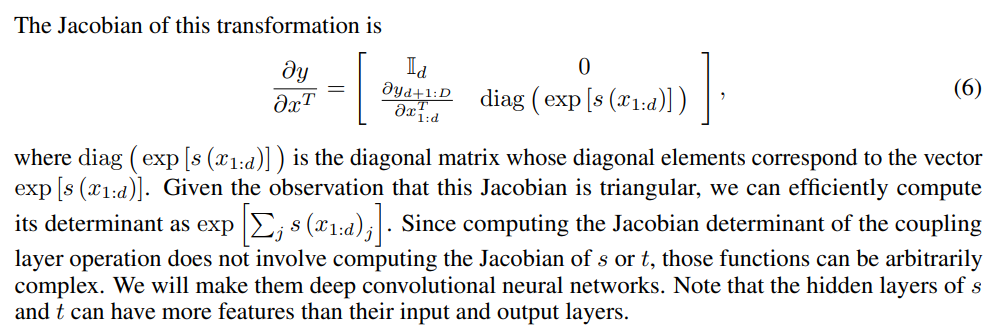

## Masking for Affine Coupling Layers for Image Modelling

#### We use two masking strategy
1. Spatial Checkboard-masking
2. Channel-wise masking

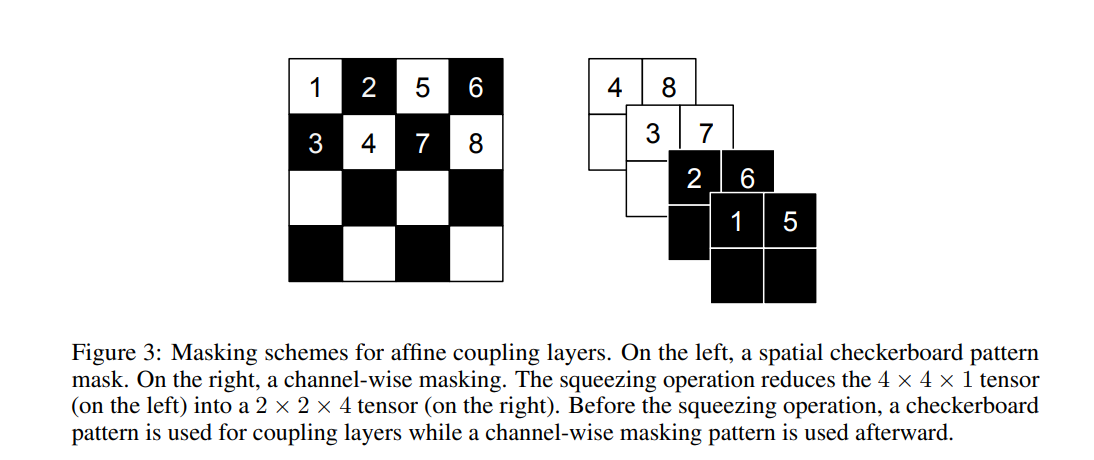

## Masking logic
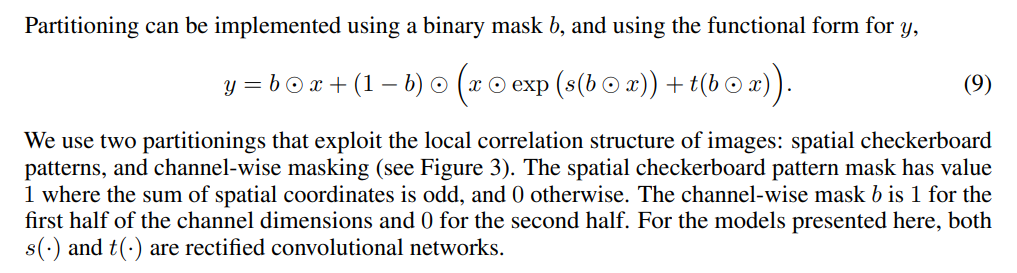

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Implementing these 2 masking techniques

In [3]:
class Masking(nn.Module):
    """
    This class implements 2 masking strategy discussed in this paper: DENSITY ESTIMATION USING REAL NVP
    paper link: https://arxiv.org/pdf/1605.08803

    # 2 types of Masking discussed in the paper was

    1. Check-board pattern masking (applied before the squeezing operator)
    2. Channel-wise masking (applied after the squeezing operator)

    Input Shape: [B, C, H, W]
    Output Shape: [B, C, H, W]
    """
    def __init__(self, x: torch.Tensor):
        super().__init__()
        self.x = x

    def forward(self, mask_type: str, first_half: bool | None, alternating: bool):
        """
        Get the interested masking type, based on 'mask_type' parameter
        if mask_type == channel_wise then parameter 'first_half' needs to be specified
        else 'first_half' must be None
        """
        return self._get_mask(self.x, mask_type = mask_type, first_half = first_half, alternating = alternating)
    
    # Check-board masking: we use this masking before the squeezing operator
    def _get_check_board_masking(self, x: torch.Tensor, alternating: bool = False):
        """
        if alternating == True: The spatial checkerboard pattern mask has value 0 where the sum of spatial coordinates is odd, and 1 otherwise
        if alternating == False: The spatial checkerboard pattern mask has value 1 where the sum of spatial coordinates is odd, and 0 otherwise
        """
        
        # We can also use this, this is slow and not vectorized
        # mask_loop = torch.zeros(x.shape[-2], x.shape[-1])
        # for i in range (x.shape[-2]):
        #     for j in range(x.shape[-1]):
        #         if (i+j) % 2 == 0:
        #             continue
        #         else:
        #             mask_loop[i, j] = 1

        # or, equivalent vectorized masking
        H, W = x.shape[-2], x.shape[-1]

        rows = torch.arange(H).unsqueeze(1) # creates [0, 1, 2, 3, 4, ..., H].T
        cols = torch.arange(W).unsqueeze(0) # creates [0, 1, 2, 3, 4, ..., H]
        # after adding we have all possible sum of pairs of (x, y) coordiantes, then '%2' creates checkerboard pattern
        if alternating:
            mask = 1 - ((rows + cols) % 2)
        else:
            mask = (rows + cols) % 2
        return mask
    
    # Channel-wise masking: we use this channel wise masking after squeezing operator
    def _get_channel_wise_masking(self, x: torch.Tensor, first_half: bool):
        """
        The channel-wise mask b is 1 for the first half of the channel dimensions and 0 for the second half
        if first_half is true then the masking is applied on the 1st half of the channel else the masking is applied on the 2nd half of the channel, maintaining the alternating pattern for masking

        NOTE: channel_wise making dsn't depends on Height, width and batch so we don't need to create the whole masking as (B, C, H, W) and (1, C, H, W) will work as fine and will produce same result when masking is applied
        This works because pytorch automatically handles the broadcasting for us

        Case-1: mask.shape = B, C, H, W and x.shape = B, C, H, W
        mask * x = B, C, H, W

        Case-2: mask.shape = 1, C, 1, 1 and x.shape = B, C, H, W
        mask * x = (1, C, 1, 1) * (B, C, H, W) => (1, C, 1, 1) will be broadcasted to (B, C, H, W) without creating extra memory and then we will get (mask * x = B, C, H, W)

        Both cases will work, but in case-2 will, memory usage is less and training speed will increase
        """
        # we can use this, but for faster training and less memory the 2nd implementation works well

        # Case-1
        # _, C, _, _ = x.shape
        # mask = torch.zeros_like(x)
        # if first_half:
        #     mask[:, :C//2, :, :] = 1
        # else:
        #     mask[:, C//2:, :, :] = 1
        # return mask


        # Case-2
        _, C, _, _ = x.shape
        mask = torch.zeros(1, C, 1, 1) # Pytorch will handle the broadcasting by its own, we don't need to create torch.zeros_like(x) for masking
        if first_half:
            mask[:, :C//2] = 1
        else:
            mask[:, C//2:] = 1
        return mask
    

    def _get_mask(self, x: torch.Tensor, mask_type: str, first_half: bool | None, alternating: bool):
        if mask_type == "check_board":
            return self._get_check_board_masking(x, alternating)
        elif mask_type == "channel_wise" and first_half is not None:
            return self._get_channel_wise_masking(x, first_half)
        else:
            print("Please select available masking [check_board, channel_wise]")


## Squeezing Operator

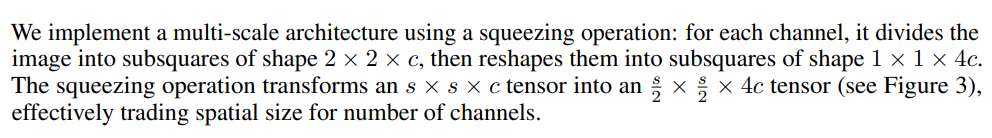

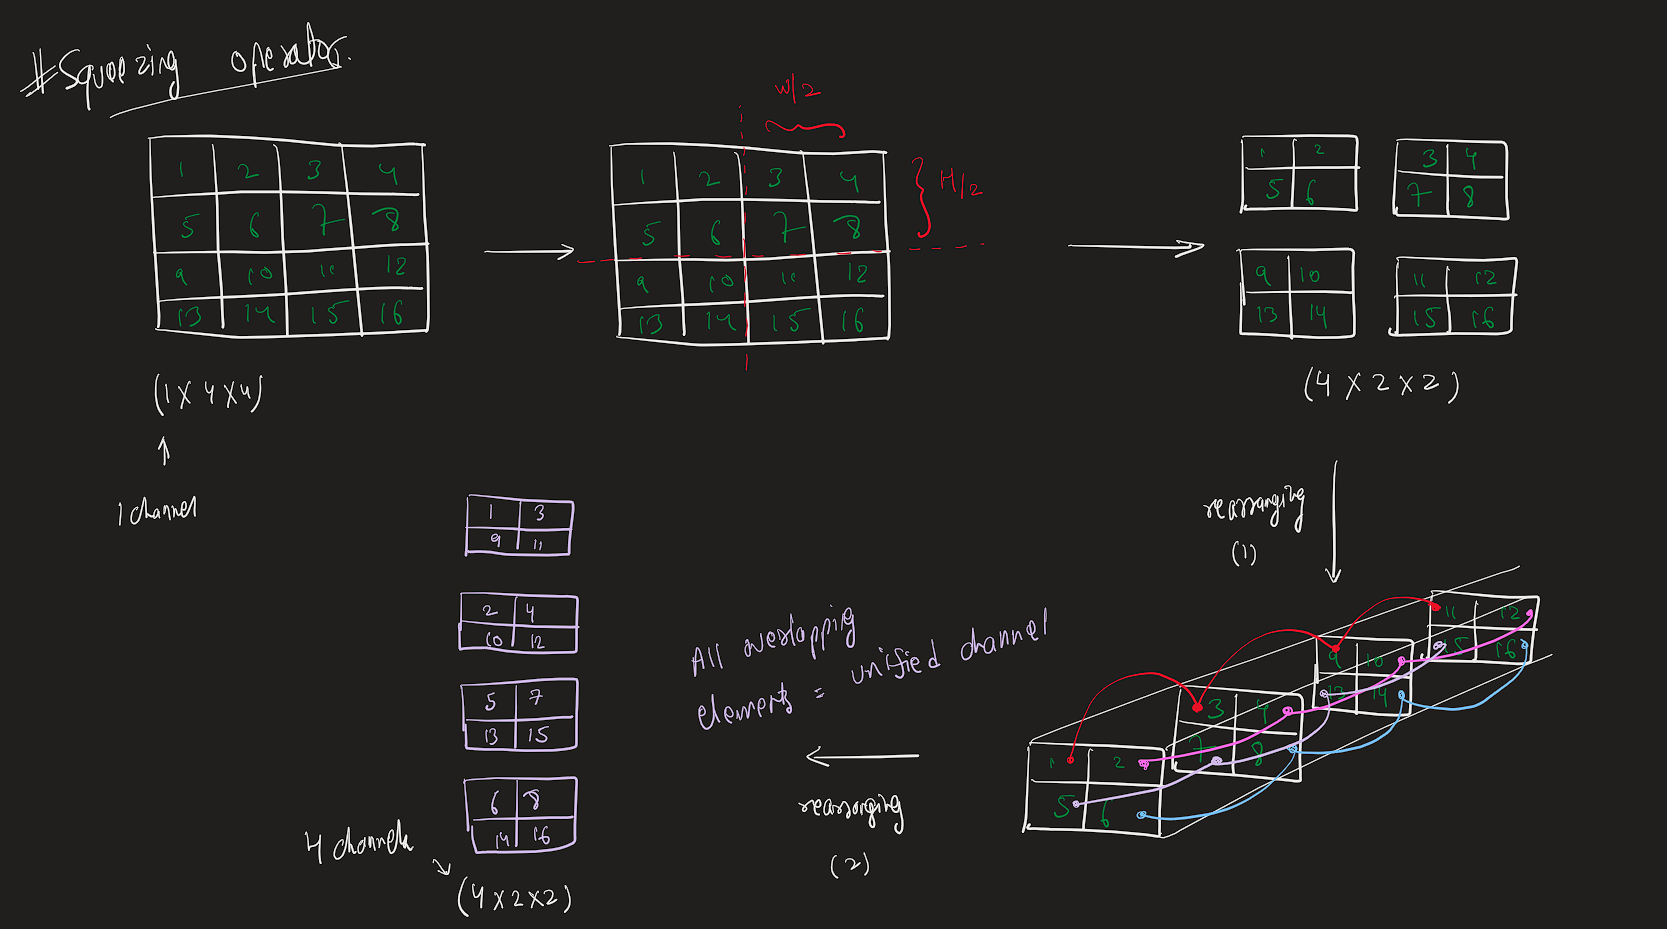

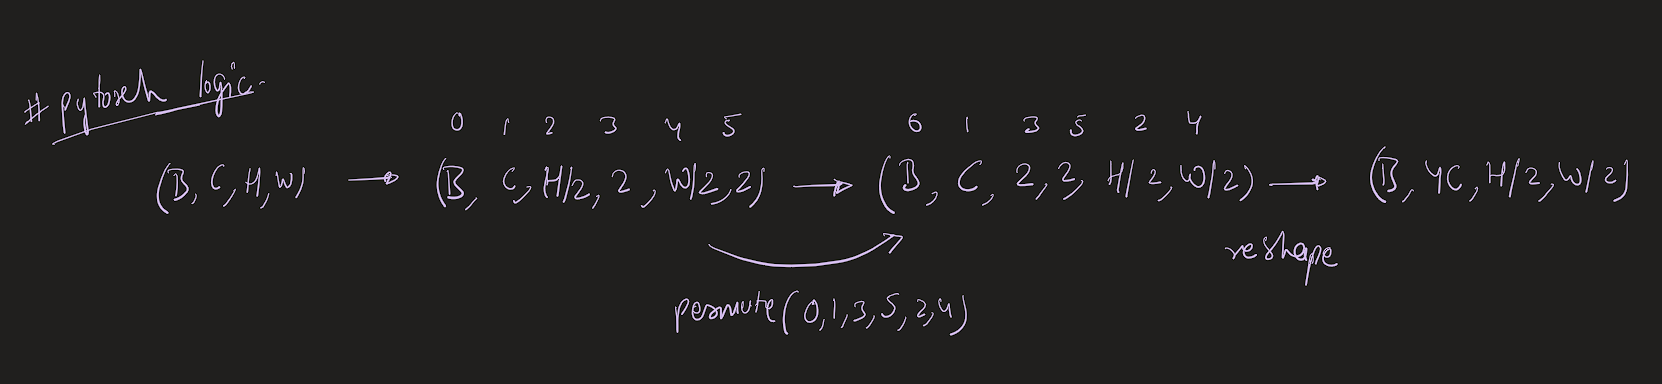

## Batch Normalization

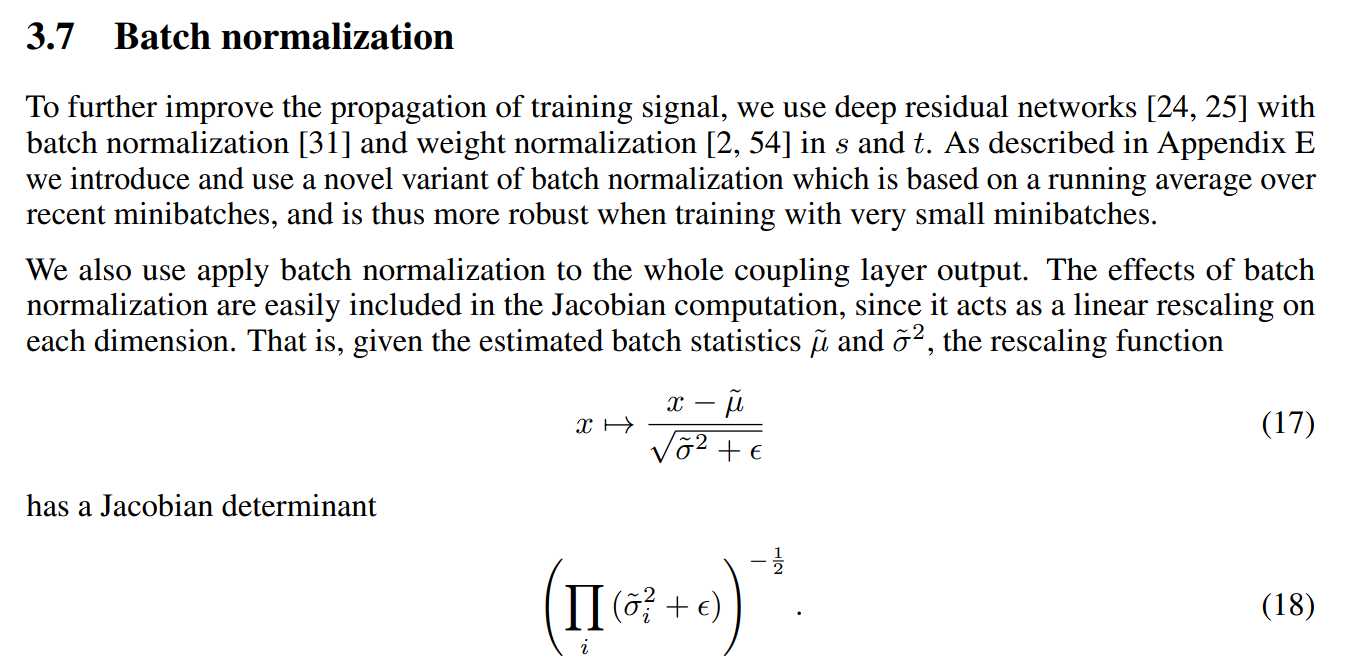

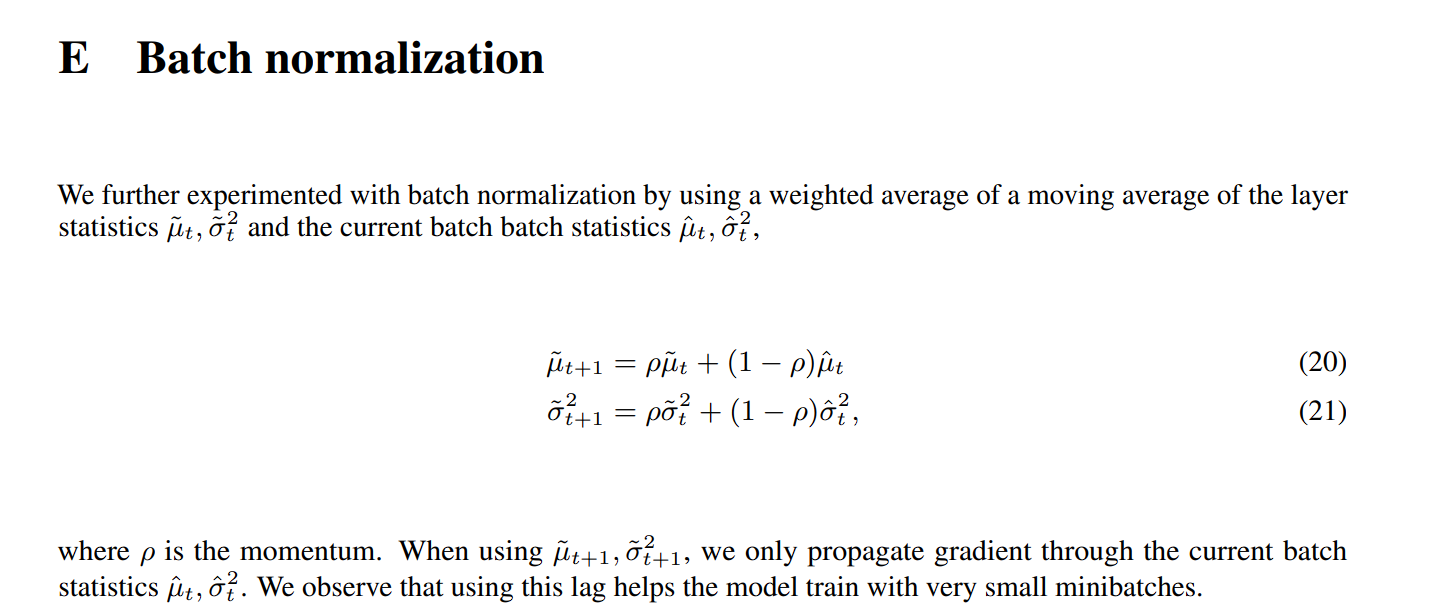

In [4]:
class BatchNormalization(nn.Module):
    """
    This implements the Batch Normalization discussed in 'Section 3.7 Batch normalization' and 'Appendix E: Batch normalization' of paper: DENSITY ESTIMATION USING REAL NVP
    paper link: https://arxiv.org/pdf/1605.08803

    I'm using the advanced version discussed in, 'Appendix E: Batch normalization'
    Which is about using batch normalization with weighted averages of a moving average of the layer

    Applies Batch Normalization over a 4D input.
    4D is a mini-batch of 2D inputs with additional channel dimension. Method described in the paper "Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift"
    paper link: https://arxiv.org/pdf/1502.03167

    Input Shape: [B, C, H, W]
    Output Shape: [B, C, H, W]
    """
    def __init__(self, in_channels: int, eps: float = 1e-5, momentum: float = 0.1):
        super().__init__()
        self.in_channels = in_channels
        self.gamma = torch.nn.Parameter(torch.ones(1, in_channels, 1, 1))
        self.beta = torch.nn.Parameter(torch.zeros(1, in_channels, 1, 1))
        self.eps = eps
        self.momentum = momentum

        # buffers (not trainable)
        self.register_buffer(
            "running_mean",
            torch.zeros(1, in_channels, 1, 1)
        )
        self.register_buffer(
            "running_var",
            torch.ones(1, in_channels, 1, 1)
        )
    
    def forward(self, x: torch.Tensor):
        if self.training:
            batch_mean = x.mean(dim = (0, 2, 3), keepdim = True)
            batch_var = x.var(dim = (0, 2, 3), keepdim = True, unbiased = False)
            self.running_mean = ((1 - self.momentum) * self.running_mean + self.momentum * batch_mean)
            self.running_var = ((1 - self.momentum) * self.running_var + self.momentum * batch_var)
            mean = batch_mean
            var = batch_var
        else:
            # if not in training mode (mode = inference mode), then use running_mean and running_var stored during training
            mean = self.running_mean
            var = self.running_var

        x_norm = (x - mean) / (torch.sqrt(var + self.eps))
        return self.gamma * x_norm + self.beta

## Flow Batch Normalization

In [5]:
class FlowBatchNorm(nn.Module):
    def __init__(self, num_channels):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(1, num_channels, 1, 1))
        self.beta = nn.Parameter(torch.zeros(1, num_channels, 1, 1))

        self.running_mean = torch.zeros(1, num_channels, 1, 1)
        self.running_var = torch.ones(1, num_channels, 1, 1)

        self.eps = 1e-5

    def forward(self, x):
        if self.training:
            mean = x.mean([0,2,3], keepdim=True)
            var = x.var([0,2,3], keepdim=True)

            self.running_mean = mean.detach()
            self.running_var = var.detach()
        else:
            mean = self.running_mean
            var = self.running_var

        x_hat = (x - mean) / torch.sqrt(var + self.eps)
        y = self.gamma * x_hat + self.beta

        # log-det
        _, _, H, W = x.shape
        log_det = torch.sum(torch.log(torch.abs(self.gamma)) - 0.5 * torch.log(var + self.eps)) * H * W

        return y, log_det
    
    def inverse(self, y):
        x_hat = (y - self.beta) / self.gamma
        x = x_hat * torch.sqrt(self.running_var + self.eps) + self.running_mean
        return x

## Squeezing Operator

In [6]:
class SqueezingOperator(nn.Module):
    """
    This Implements the Squeezing Operator discussed in 'Section 3.6 Multi-scale architecture' in the paper: DENSITY ESTIMATION USING REAL NVP
    paper link: https://arxiv.org/pdf/1605.08803

    It divides the image into subsquares of shape 2 x 2 x c, then reshapes them into subsquares of shape 1 x 1 x 4c

    For forward pass:
        Input Shape: [B, C, H, W]
        Output Shape: [B, 4*C, H/2, W/2]

    For inverse pass:
        Input Shape: [B, 4*C, H/2, W/2]
        Output Shape: [B, C, H, W]
    """
    def __init__(self):
        super().__init__()
    
    @abstractmethod
    def forward(self, x: torch.Tensor):
        return self._squeeze(x)

    def _squeeze(self, x: torch.Tensor):
        """
        
        # Why we squeeze the image?
        1. Squeezing is used to reorganize information so the model can learn dependencies more effectively
        2. without squeezing information spreads slowly across spatial positions
        """
        B, C, H, W = x.shape
        x = x.view(B, C, H//2, 2, W//2, 2) # dividing into subgroups of 2x2
        x = x.permute(0, 1, 3, 5, 2, 4) # bring subgroups of 2x2 near channel-dim
        x = x.reshape(B, 4*C, H//2, W//2)
        return x
    
    def _unsqueeze(self, x: torch.Tensor):
        # x.shape = [B, 4*C, H/2, W/2]
        B, C, H, W = x.shape
        x = x.reshape(B, C//4, 2, 2, H, W)
        x = x.permute(0, 1, 4, 2, 5, 3)
        x = x.reshape(B, C//4, 2*H, 2*W)
        return x

    
    def inverse(self, x: torch.Tensor):
        return self._unsqueeze(x)


# Usage:

# s = SqueezingOperator()
# x = torch.rand(1, 4, 64, 64)
# squ_x = s(x)
# unsqu_x = s.inverse(squ_x)
# print(f"x = {x[0, 0, 0, :5]}")
# print(f"squeeze_x = {squ_x[0, 0, 0, :5]}")
# print(f"unsqueeze_x = {unsqu_x[0, 0, 0, :5]}")

## Residual Skip Connections

In [7]:
class ResidualSkipConnections(nn.Module):
    """
    Implementing Residual Skip connections for efficient gradient flow as discussed in the paper: DENSITY ESTIMATION USING REAL NVP
    paper link: https://arxiv.org/pdf/1605.08803

    Input Shape: [B, C, H, W]
    Output Shape: [B, C, H, W]
    """
    def __init__(self, function: nn.Module):
        super().__init__()
        self.function = function

    def forward(self, x: torch.Tensor):
        out = self.function(x)
        return x + out

In [8]:
class Block(nn.Module):
    """
    This denotes 1 block of the scale and shift network, we repeat multiple blocks in scale and shift Network to make complex deep neural nets
    Defination of 1 Block:
    [
        ResidualSkipConnections(Conv2d() --> BatchNorm() --> Conv2d() --> BatchNorm() --> Conv2d() --> BatchNorm()) 
        --> Relu()
    ] x 5

    Input Shape: [B, C, H, W]
    Output Shape: [B, C, H, W]
    """
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        assert in_channels == out_channels, "in_channels must be equal to out_channels"
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.conv1 = nn.Conv2d(in_channels = self.in_channels, out_channels = 32, kernel_size = 3, stride = 1, padding = 1) # Using padding  = 1, because I want h_in = h_out ==> x_in.shape == x_out.shape after applying scale and shift transformation
        self.batchnorm2d_1 = BatchNormalization(in_channels = 32)
        self.conv2 = nn.Conv2d(in_channels = 32, out_channels = 32, kernel_size = 3, stride = 1, padding = 1)
        self.batchnorm2d_2 = BatchNormalization(in_channels = 32)
        self.conv3 = nn.Conv2d(in_channels = 32, out_channels = self.out_channels, kernel_size = 3, stride = 1, padding = 1)
        self.batchnorm2d_3 = BatchNormalization(in_channels = self.out_channels)
    
    def forward(self, x: torch.Tensor):
        x = self.conv1(x)
        x = self.batchnorm2d_1(x)
        x = self.conv2(x)
        x = self.batchnorm2d_2(x)
        x = self.conv3(x)
        x = self.batchnorm2d_3(x)
        return x

## Scale and Shift Neural Network

In [9]:
class ScaleAndShiftNetwork(nn.Module):
    """
    This class implements the scale and shift logic discussed in this paper: DENSITY ESTIMATION USING REAL NVP
    paper link: https://arxiv.org/pdf/1605.08803

    This Class can be very complex Neural Network because the Jacobian determinant have no contribution for this component
    as discussed in the the above paper in section 3.3 Properties "We will make them deep convolutional neural networks", i'll also implement this scale and shift network as deep CNNs

    In section (3.7 Batch normalization) they also discussed to apply Batch Normalization (novel variant) with residual connections and weight normalization to implement this scale and shift networks
    Novel variant of batch normalization is discussed in Appendix E, which is based on a running average over recent minibatches

    No MaxPooling or squeeze is used inside scale and shift networks because spatial dimensions must remain unchanged for affine coupling

    Architecture of Scale and Shift Network as Deep CNNs:
    [
        ResidualSkipConnections(Conv2d() --> BatchNorm() --> Conv2d() --> BatchNorm()) 
        --> Relu()
    ] x 5
    Residual Skip Connections will wrap Conv2d, BatchNorm and not relu

    Input Shape: [B, C, H, W]
    Output Shape: [B, C, H, W]
    """
    def __init__(self, in_channels: int, out_channels: int, n_layers: int):
        super().__init__()
        assert in_channels == out_channels, "in_channels must be equal to out_channels"
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.cnn_layer = nn.ModuleList([
            ResidualSkipConnections(Block(self.in_channels, self.out_channels))
            for _ in range(n_layers)
        ])
        self.scale_layer = nn.Conv2d(in_channels = out_channels, out_channels = out_channels, kernel_size = 3, padding = 1, stride = 1)
        self.shift_layer = nn.Conv2d(in_channels = out_channels, out_channels = out_channels, kernel_size = 3, padding = 1, stride = 1)
        nn.init.zeros_(self.scale_layer.weight)
        nn.init.zeros_(self.scale_layer.bias)
    
    def forward(self, x: torch.Tensor):
        for layer in self.cnn_layer:
            x = layer(x)
            x = torch.relu(x)
        return self.scale_layer(x), self.shift_layer(x)

## Affine Coupling Layer

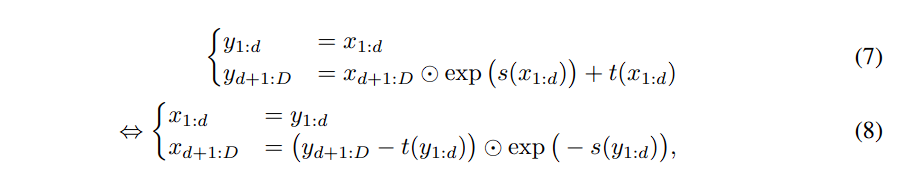

In [10]:
class AffineCouplingLayer(nn.Module):
    """
    This class Implements the affine coupling layer using Masked convolution, as discussed in "section 3.4 Masked convolution" of paper: DENSITY ESTIMATION USING REAL NVP
    paper link: https://arxiv.org/pdf/1605.08803

    b = binary_mask (spatial checkerboard pattern mask or channel-wise mask)
    x = input_vector

    In-practice we will get (x_a, x_b) = (b * x, (1-b) * x)
    (y_a, y_b) = (exp(scale(x_b) * x_a + shift(x_b)), x_b)
    where 'x_b' is left unchanged

    Input Shape: [B, C, H, W]
    Output Shape: [B, C, H, W]
    """
    def __init__(self, mask_type: str, first_half: bool | None, in_channel: int, out_channel: int, n_layers: int, alternating_check_board: bool = False):
        super().__init__()
        assert in_channel == out_channel, "in_channels must be equal to out_channels"
        self.mask_type = mask_type
        self.alternating_check_board = alternating_check_board
        self.first_half = first_half
        self.scale_shift = ScaleAndShiftNetwork(in_channels = in_channel, out_channels = out_channel, n_layers = n_layers)
    
    def get_mask(self, x):
        if not hasattr(self, "_mask") or self._mask.shape[1:] != x.shape[1:]:
            mask_module = Masking(x)
            self._mask = mask_module(
                mask_type=self.mask_type,
                first_half=self.first_half,
                alternating=self.alternating_check_board
            )
        return self._mask.to(x.device)

    def forward(self, x: torch.Tensor):
        b = self.get_mask(x)
        scale, shift = self.scale_shift(b * x)
        scale = 0.03 * torch.tanh(scale)
        scale = torch.clamp(scale, -2, 2)
        y = b * x + (1- b) * (x * torch.exp(scale) + shift)
        log_det = (1-b) * scale

        return y, log_det # <---- This is for the Determinant of the Jacobian matrix
    
    def inverse(self, y: torch.tensor):
        """
        Calculates the inverse of Affine Coupling Layer, the defination of this inverse is attached in the above markdown cell
        """
        b = self.get_mask(y)

        y1, y2 = y * b, y * (1 - b)
        s, t = self.scale_shift(y1)
        s = 0.03 * torch.tanh(s)
        s = torch.clamp(s, -2, 2)
        x1 = y1
        x2 = (1 - b) * (y2 - t) * torch.exp(-s)
        return x1 + x2

# Usage:

# x = torch.randn(2, 3, 64, 64)
# layer = AffineCouplingLayer(
#     mask_type="check_board",
#     first_half=None,
#     in_channel=3,
#     out_channel=3,
#     n_layers=5,
#     alternating_check_board=False
# )
# y, _ = layer(x)
# x_hat = layer.inverse(y)
# print((x - x_hat).abs().max())

## Multi-scale Architecture

In [11]:
class ScaleBlock(nn.Module):
    """
    This imnplements one Scale block of the Multi-scale Architecture discussed in Multi-scale architecture discussed in 'section 3.6 Multi-scale architecture' of paper: DENSITY ESTIMATION USING REAL NVP
    paper link: https://arxiv.org/pdf/1605.08803


    It first applies three coupling layers (AffineCouplingLayer)
    with alternating checkerboard masks, then perform a squeezing operation, and finally apply three
    more coupling layers with alternating channel-wise masking
    For the final scale, it only applies four coupling layers with alternating checkerboard masks <----- Implemented by 'FinalScaleBlock' class

    Architecture:
    Each Scale: Defined here in ScaleBlock class
        AffineCouplingLayer() x 3 (use alternating checkerboard masking)
        SqueezingOperation()
        AffineCouplingLayer() x 3 (use alternating channel-wise masking)
        SplitLatent()
    Final Scale: Defined in FinalScaleBlock class
        AffineCouplingLayer() x 4 (use alternating checkerboard masking)

    
    Each Scale:
    Produces latent chunk


    Input Shape: [B, C, H, W]
    Output Shape: [B, 4*C, H/2, W/2] <--- because of SqueezingOperator()
    """
    def __init__(self, in_channel: int, out_channel: int, n_scale_shift_layers: int):
        super().__init__()
        self.check_board_layer = nn.ModuleList([
            AffineCouplingLayer(mask_type = "check_board", alternating_check_board = False, first_half = None, in_channel = in_channel, out_channel = out_channel, n_layers = n_scale_shift_layers),
            FlowBatchNorm(out_channel),
            AffineCouplingLayer(mask_type = "check_board", alternating_check_board = True, first_half = None, in_channel = in_channel, out_channel = out_channel, n_layers = n_scale_shift_layers),
            FlowBatchNorm(out_channel),
            AffineCouplingLayer(mask_type = "check_board", alternating_check_board = False, first_half = None, in_channel = in_channel, out_channel = out_channel, n_layers = n_scale_shift_layers)
        ])

        self.squeeze = SqueezingOperator() # <----- After performing this, in_channel get's changed, it gets 4 * original_in_channel

        self.channel_wise_layer = nn.ModuleList([
            AffineCouplingLayer(mask_type = "channel_wise", first_half = True, in_channel = 4 * in_channel, out_channel = 4 * out_channel, n_layers = n_scale_shift_layers),
            FlowBatchNorm(4 * out_channel),
            AffineCouplingLayer(mask_type = "channel_wise", first_half = False, in_channel = 4 * in_channel, out_channel = 4 * out_channel, n_layers = n_scale_shift_layers),
            FlowBatchNorm(4 * out_channel),
            AffineCouplingLayer(mask_type = "channel_wise", first_half = True, in_channel = 4 * in_channel, out_channel = 4 * out_channel, n_layers = n_scale_shift_layers)
        ])

    
    def forward(self, x: torch.Tensor):
        # Apply 1st 3-layers of ScaleBlock
        log_det = 0
        for layer in self.check_board_layer:
            x, ld = layer(x) # x.shape = (B, C, H, W) ---> x.shape = (B, C, H, W)
            if ld.ndim == 4:
                log_det += torch.sum(ld, dim=[1,2,3])
            else:
                log_det += ld
        
        # Squeeze it
        x = self.squeeze(x) # x.shape = (B, C, H, W) ---> x.shape = (B, 4*C, H/2, W/2)


        # Apply last 3 layers of ScaleBlock
        for layer in self.channel_wise_layer:
            x, ld = layer(x) # x.shape = (B, 4*C, H/2, W/2) ---> x.shape = (B, 4*C, H/2, W/2)
            if ld.ndim == 4:
                log_det += torch.sum(ld, dim=[1,2,3])
            else:
                log_det += ld

        # Next ScaleBlock's check_board_layer will expect the tensor of shape (B, C, H, W) but right now the shape of x tensor is (B, 4*C, H/2, W/2) --> mismatch in shape, therefore we use Latent vector splitting

        # Split
        B, C, H, W = x.shape
        z = x[:, :C//2]
        x_remaining = x[:, C//2:]
        # Now next layer will get this x_remaining (x_remaining.shape = [B, 2*C, H/2, W/2])
        return x_remaining, z, log_det
    
    def inverse(self, x_remaining: torch.Tensor, z: torch.Tensor):
        """
        Aim is to re-create input x from x_remaining and z which is a very complex transformation of x
        """
        B, C, H, W = x_remaining.shape
        x = torch.cat([z, x_remaining], dim=1)

        for layer in self.channel_wise_layer[::-1]:
            x = layer.inverse(x)

        x = self.squeeze.inverse(x)

        for layer in self.check_board_layer[::-1]:
            x = layer.inverse(x)
        
        return x
        
# Usage:

# x = torch.rand(2, 10, 10, 10)
# s = ScaleBlock(10,10, 2)
# x_r, z = s(x)
# x_inverse = s.inverse(x_r, z)
# print(f"x = {x[0, 0, 0, :5]}")
# print(f"x_inverse = {x_inverse[0, 0, 0, :5]}")
# print(f"Log(|J|) = {s.log_J()}")

In [12]:
class FinalScaleBlock(nn.Module):
    """
    Implements the Final Scale Layer discussed in Multi-scale architecture discussed in 'section 3.6 Multi-scale architecture' of paper: DENSITY ESTIMATION USING REAL NVP
    paper link: https://arxiv.org/pdf/1605.08803

    For the final scale, we only apply four coupling layers with alternating checkerboard masks
    """
    def __init__(self,  in_channel: int, out_channel: int, n_scale_shift_layers: int):
        super().__init__()
        self.final_scale_check_board_layer = nn.ModuleList([
            AffineCouplingLayer(mask_type = "check_board", alternating_check_board = False, first_half = None, in_channel = in_channel, out_channel = out_channel, n_layers = n_scale_shift_layers),
            AffineCouplingLayer(mask_type = "check_board", alternating_check_board = True, first_half = None, in_channel = in_channel, out_channel = out_channel, n_layers = n_scale_shift_layers),
            AffineCouplingLayer(mask_type = "check_board", alternating_check_board = False, first_half = None, in_channel = in_channel, out_channel = out_channel, n_layers = n_scale_shift_layers),
            AffineCouplingLayer(mask_type = "check_board", alternating_check_board = True, first_half = None, in_channel = in_channel, out_channel = out_channel, n_layers = n_scale_shift_layers)
        ])

    def forward(self, x: torch.Tensor):
        log_det = 0 
        for layer in self.final_scale_check_board_layer:
            x, scales_i = layer(x)
            log_det += torch.sum(scales_i, dim = [1, 2, 3])

        return x, log_det

    def inverse(self, y: torch.Tensor):
        x = y
        for layer in self.final_scale_check_board_layer[::-1]:
            x = layer.inverse(x)
        return x

# Usage:
# x = torch.rand(1, 10, 10, 10)
# f = FinalScaleBlock(10, 10, 5)
# y = f(x)
# x_inverse = f.inverse(y)
# x[0, 0, 0, :5], x_inverse[0, 0, 0, :5]

## Model

In [13]:
class RectifiedCNNRNVPModel(nn.Module):
    """
    This implements the Multi-scale architecture discussed in 'section 3.6 Multi-scale architecture' of paper: DENSITY ESTIMATION USING REAL NVP
    paper link: https://arxiv.org/pdf/1605.08803

    Idea: Stack several Scale Blocks (Defined by 'ScaleBlock'), and at the end we use one Final Scale block (defined by 'FinalScaleBlock' class)
    """
    def __init__(self, in_channel: int, n_scale_shift_layers: int, n_scale_blocks: int):
        super().__init__()
        channels = in_channel
        self.scale_blocks = nn.ModuleList()

        for _ in range(n_scale_blocks):
            self.scale_blocks.append(
                ScaleBlock(in_channel = channels, out_channel = channels, n_scale_shift_layers = n_scale_shift_layers)
            )
            channels = 2 * channels  # <---- Because of Squeezing Operator we have x.shape = `[B, 4*C, H//2, W//2]` and then after splitting at the end of ScaleBlock we have `x_remaining.shape = [B, 2*C, H//2, W//2]`, so per forward pass of ScaleBlock, channel size increases by the multiple of 2

        self.final_scale_block = FinalScaleBlock(in_channel = channels, out_channel = channels, n_scale_shift_layers = n_scale_shift_layers)

    def forward(self, x: torch.Tensor):
        z_list = []
        log_det_total = 0
        self.z_list_shapes = []
        for layer in self.scale_blocks:
            x, z, log_det = layer(x)
            z_list.append(z) # <---- Each z in this z_list have different shape, eg: z1.shape = [B, 64, 64, 64] and z2.shape = [B, 128, 32, 32] and so on
            self.z_list_shapes.append(z.shape) # <--- I'm Storing each `z's` shape, because I need to re-store each `z` in inverse mapping and each z have different shape
            log_det_total += log_det
        
        x, log_det = self.final_scale_block(x)
        z_list.append(x)
        self.z_list_shapes.append(x.shape)

        log_det_total += log_det

        z = torch.cat(
            [zi.flatten(start_dim=1) for zi in z_list],
            dim=1
        )

        return z, log_det_total
    
    def inverse(self, z):

        B = z.shape[0]
        shapes = self.z_list_shapes

        # compute flat sizes
        sizes = [C*H*W for (_, C, H, W) in shapes]

        # splitting the z's into z_i each of different shape
        z_chunks = torch.split(z, sizes, dim=1)

        # reshape
        z_restored = [
            zc.view(B, C, H, W)
            for zc, (_, C, H, W) in zip(z_chunks, shapes)
        ]

        # final block inverse
        x = self.final_scale_block.inverse(z_restored[-1])

        # 5. scale blocks inverse
        for block, zi in zip(self.scale_blocks[::-1], z_restored[:-1][::-1]):
            x = block.inverse(x, zi)

        return x

# Usage:
# x = torch.rand(2,3,64,64)

# model = RectifiedCNNRNVPModel(
#     in_channel=3,
#     n_scale_shift_layers=5,
#     n_scale_blocks=3
# )
# model = model.double()
# x = x.double()
# z, log_J = model(x)
# print(f"x = {x[0, 0, 0, :5]}")
# print(f"y_inverse = {model.inverse(z)[0, 0, 0, :5]}")
# print(f"Log|J| = {model.log_J()}")

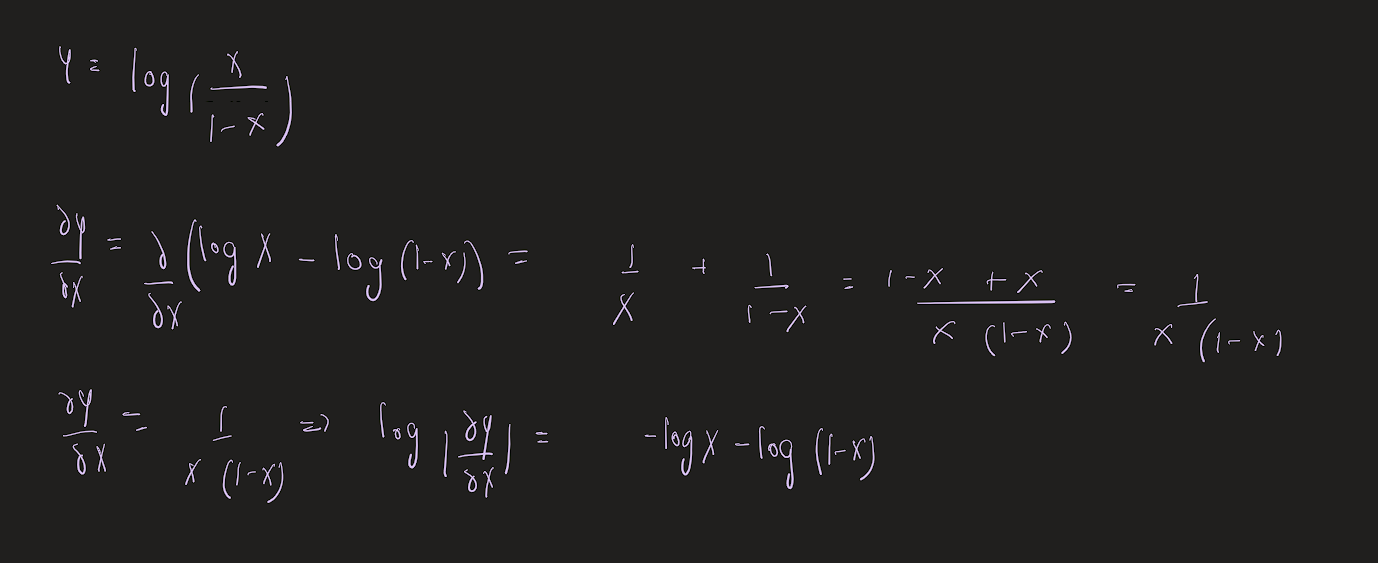

In [14]:
class Dequantization(nn.Module):
    """
    This implements the dequantization  logic discussed in paper: DENSITY ESTIMATION USING REAL NVP
    paper link: https://arxiv.org/pdf/1605.08803

    The Problem:
        Model Assumes the Data as,
            x ∈ R (continuous, unbounded)
        But images are x ∈ {0,1,...,255}  
        → discrete (Problem)
        → scaled to [0,1]  → bounded (Problem)

        we want out image to lie in continous space and must be unbounded

        Solution: 
            1. Use Dequantization and Logit Transform
    
    This class is Only Resposible for dequantization and [logit transform (discussed in 4.1 Procedure) must be implemented in another module]
    """
    def __init__(self):
        super().__init__()

    @abstractmethod
    def forward(self, x: torch.Tensor):
        return x + (torch.rand_like(x) / 256.0)

class LogitTransform(nn.Module):
    """
    This Implements the Logit Transformation logic (discussed in 4.1 Procedure) of paper: DENSITY ESTIMATION USING REAL NVP
    paper link: https://arxiv.org/pdf/1605.08803

    Problem: Images are bounded in nature [0, 256] or scaled version are bounded in [0, 1] we want an unbounded space
    
    Solution: so we transform out image as, logit(a + (1 - a) x), where a = 0.05 and then applies log for removing the bounds

    We use this after the Dequantization step
    """
    def __init__(self):
        super().__init__()

    
    @abstractmethod
    def forward(self, x: torch.Tensor, alpha: float = 1e-6):
        eps = 1e-6
        x = alpha + (1 - 2 * alpha) * x
        x = torch.clamp(x, 1e-6, 1 - 1e-6)
        y = torch.log(x + eps) - torch.log(1 - x + eps)

        # get the log_det or log(del(y)/del(x))
        log_det = torch.sum(
            -torch.log(x + eps) - torch.log(1 - x + eps),
            dim = [1, 2, 3]
        )

        return y, log_det

In [15]:
import math
LOG_2PI = math.log(2 * math.pi)
def log_pz(z: torch.Tensor):
    return -0.5 * (LOG_2PI + z ** 2)

In [16]:
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

def visualize_flow(model, loader, device, epoch, num_samples=64):
    model.eval()

    with torch.no_grad():

        # 1. Generate samples (z → x)
        z_dim = None

        # infer latent size from one batch
        for images, _ in loader:
            images = images.to(device)
            x = images[:1]
            z, _ = model(x)
            z_dim = z.shape[1]
            break

        z = torch.randn(num_samples, z_dim).to(device)
        x_gen = model.inverse(z)

        # bring back to [0,1] (approx)
        x_gen = torch.sigmoid(x_gen)  # since logit was used

        grid = make_grid(x_gen, nrow=8)
        plt.figure(figsize=(6,6))
        plt.title(f"Generated Samples (Epoch {epoch})")
        plt.imshow(grid.permute(1,2,0).cpu())
        plt.axis("off")
        plt.show()

        # 2. Latent space visualization
        images, _ = next(iter(loader))
        images = images.to(device)

        x = images[:256]  # small batch
        z, _ = model(x)

        z = z.detach().cpu()

        # use first 2 dims
        z_2d = z[:, :2]

        plt.figure(figsize=(5,5))
        plt.scatter(z_2d[:,0], z_2d[:,1], s=5, alpha=0.6)
        plt.title(f"Latent Space (Epoch {epoch})")
        plt.xlabel("z1")
        plt.ylabel("z2")
        plt.show()

    model.train()

## Logic for Saving and Loading the Model

In [17]:
import os

def save_checkpoint(model, optimizer, epoch, path="../saved_models/checkpoint.pth"):
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
    }, path)


def load_checkpoint(model, optimizer, path="checkpoint.pth", device="cuda"):
    if not os.path.exists(path):
        return 0  # start from scratch

    checkpoint = torch.load(path, map_location=device)

    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])

    print(f"Resumed from epoch {checkpoint['epoch']}")
    return checkpoint["epoch"]

def save_periodic(model, optimizer, epoch, save_dir="checkpoints"):
    os.makedirs(save_dir, exist_ok=True)
    path = os.path.join(save_dir, f"model_epoch_{epoch}.pth")

    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
    }, path)

    print(f"Saved periodic checkpoint → {path}")


def save_best(model, optimizer, epoch, best_idx, loss, save_dir="checkpoints"):
    os.makedirs(save_dir, exist_ok=True)

    path = os.path.join(save_dir, f"best_{best_idx:02d}_epoch_{epoch}_loss_{loss:.2f}.pth")

    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "loss": loss
    }, path)

    print(f"New best model saved → {path}")

In [18]:
from tqdm import tqdm
import torch

def train_model(model, optimizer, epochs, loader, device="cuda", ckpt_path="checkpoint.pth"):
    print(f"Training on device = [{device}]")

    model.to(device)
    model.train()

    dequant = Dequantization().to(device)
    logit = LogitTransform().to(device)

    # Resume
    start_epoch = load_checkpoint(model, optimizer, ckpt_path, device)

    best_loss = float("inf")
    best_idx = 1

    for epoch in range(start_epoch, epochs):

        epoch_log_pz = 0
        epoch_log_J = 0
        epoch_log_det = 0

        progress_bar = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)

        for images, _ in progress_bar:
            images = images.to(device, non_blocking=True)

            x = dequant(images)
            x, log_det_logit = logit(x)

            z, log_J = model(x)
            D = z.shape[1]

            log_pz_val = log_pz(z).flatten(1).sum(dim=1)
            loss = -(log_pz_val + log_J + log_det_logit) / D # normalize
            loss = loss.mean()

            if torch.isnan(loss):
                print(f"NaN detected, stopping training at epoch = {epoch+1}")
                return model

            epoch_log_pz += log_pz_val.mean().item()
            epoch_log_J += log_J.mean().item()
            epoch_log_det += log_det_logit.mean().item()

            optimizer.zero_grad()
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

            progress_bar.set_postfix({
                "loss": f"{loss.item():.3f}",
                "log_pz": f"{log_pz_val.mean().item():.2f}",
                "log_J": f"{log_J.mean().item():.2f}",
                "ratio": f"{log_J.mean() / abs(log_pz_val.mean()):.3f}"
            })

        num_batches = len(loader)

        avg_loss = -(epoch_log_pz/num_batches + epoch_log_J/num_batches + epoch_log_det/num_batches)

        print(f"[{epoch+1}/{epochs}] "
              f"log_pz: {epoch_log_pz/num_batches:.5f} | "
              f"log_J: {epoch_log_J/num_batches:.5f} | "
              f"log_det: {epoch_log_det/num_batches:.5f} | "
              f"loss: {avg_loss:.5f}")

        if avg_loss < best_loss:
            best_loss = avg_loss
            save_best(model, optimizer, epoch+1, best_idx, best_loss)
            best_idx += 1

        if (epoch + 1) % 30 == 0:
            save_periodic(model, optimizer, epoch+1)

        save_checkpoint(model, optimizer, epoch+1, ckpt_path)

        if (epoch + 1) % 10 == 0:
            visualize_flow(model, loader, device, epoch+1)

    return model

## Loading Dataset

In [19]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(
    root="../data/celeba",
    transform=transform
)

loader = DataLoader(dataset, batch_size=64, shuffle=True)

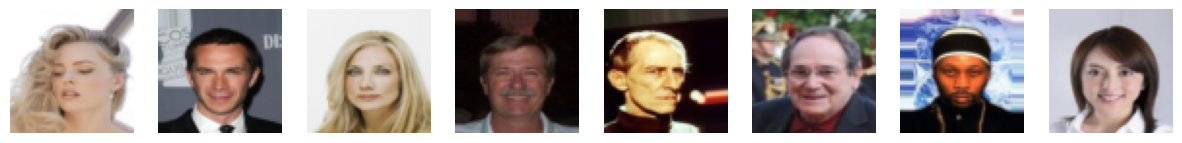

In [20]:
import matplotlib.pyplot as plt

images, labels = next(iter(loader))

fig, axes = plt.subplots(1, 8, figsize=(15,3))

for i in range(8):
    axes[i].imshow(images[i].permute(1,2,0))
    axes[i].axis("off")

plt.show()

## Build the Model

In [ ]:
from torch.utils.data import DataLoader


## Build the Model
images, labels = next(iter(loader))
x = images[0]

C, H, W = x.shape
model = RectifiedCNNRNVPModel(
    in_channel = C,
    n_scale_shift_layers = 2,
    n_scale_blocks = 2
)


# Training Settings
EPOCHS = 110
lr = 1e-5
optimizer = torch.optim.Adam(model.parameters(), lr = lr, weight_decay = 1e-5)


loader = DataLoader(
    dataset,
    batch_size = 64,
    shuffle=True,        
    num_workers=2,       
    pin_memory=True      
)

## Train the Model

In [ ]:
trained_model = train_model(model, optimizer = optimizer, epochs = EPOCHS, loader = loader, device = device)

Training on device = [cuda]


Epoch 1/110:  96%|█████████▌| 353/367 [02:52<00:06,  2.13it/s, loss=-1.723, log_pz=-17271.12, log_J=11299.36, ratio=0.654]

### Completed so far:
1. Understood coupling layers
2. Implemented checkerboard masking
3. Implemented channel-wise masking
4. Understood broadcasting optimization
5. Implemented squeeze operation correctly
6. Designed modular architecture
7. Identified multi-scale factoring but intentionally postponed it
8. Implement Scale and Shift Network (using rectified convolutions)
9. Implement Residual Skip Connections
10. Implement Batch Normalization
11. Implement Affine Coupling Layer
12. Implement Forward Block of the entire network
13. Implement Inverse of this invertible functio
14. Implement multi-scale factoring
15. Implement Inverse mapping for each invertible functions
16. Implement inverse for SqueezingOperator also
17. Implemented inverse mapping for entire model (handled concat and flattening logic of latent variable `z`)
18. Storage of |J| (Determinant Jacobian)
19. dequantization and scaling of images (as described in the paper) and add the contribution of it in Log_J as `log p(x) = log p(z) + log|det J_flow| + log|det J_logit|`
20. Convert all tensor to device
21. Build Model
22. Write training loop and handle dataloading loop
23. Train the Model

### Todo:
1. Monitor training and Visualize results, Debug errors